In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [5]:
base = Path.cwd()
if not (base / "data").exists():
    base = base.parent

X_train = pd.read_csv(base / "data/processed/train/X_train.csv")
X_val = pd.read_csv(base / "data/processed/val/X_val.csv")
X_test = pd.read_csv(base / "data/processed/test/X_test.csv")

y_train = pd.read_csv(base / "data/processed/train/y_train.csv").values.ravel()
y_val = pd.read_csv(base / "data/processed/val/y_val.csv").values.ravel()
y_test = pd.read_csv(base / "data/processed/test/y_test.csv").values.ravel()

print("Data loaded")

Data loaded


In [6]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1427431, 78)
X_test: (225711, 78)


In [7]:
#check shape of training and testing data
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1427431, 78)
X_test: (225711, 78)


In [8]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained SUCCESFULLY")

Model trained SUCCESFULLY


In [9]:
y_pred = model.predict(X_test)

In [10]:
#calculation of metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7923140653313308
Precision: 0.9989301787954059
Recall: 0.6345245069322398
F1-score: 0.7760799056112578


In [11]:
print(y_train.mean())
print(y_test.mean())

0.24014891087555196
0.5672076239084493


In [12]:
#Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
print("False Positive Rate:", fpr)
print("Confusion Matrix:\n", cm)

False Positive Rate: 0.0008906086849702106
Confusion Matrix:
 [[97599    87]
 [46790 81235]]


In [13]:
#Check the rate of false positive 
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
print("False Positive Rate:", fpr)

False Positive Rate: 0.0008906086849702106


In [14]:
import sys
print(sys.executable)

c:\Users\Ihfaz\AppData\Local\Programs\Python\Python313\python.exe


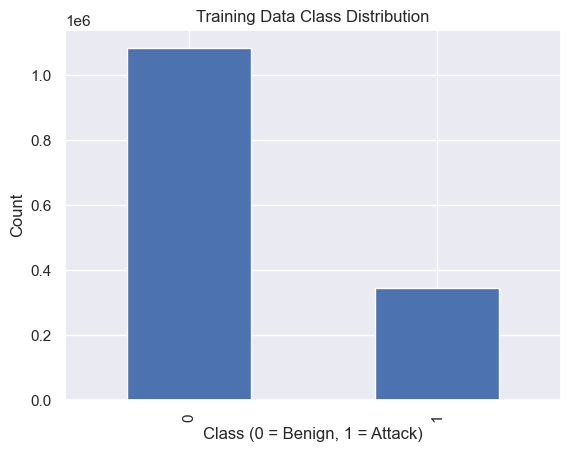

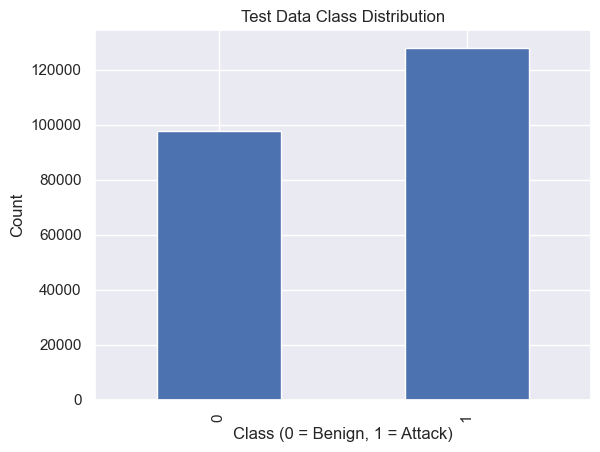

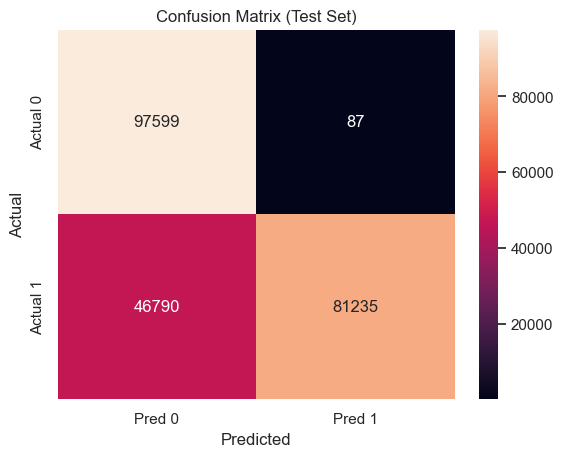

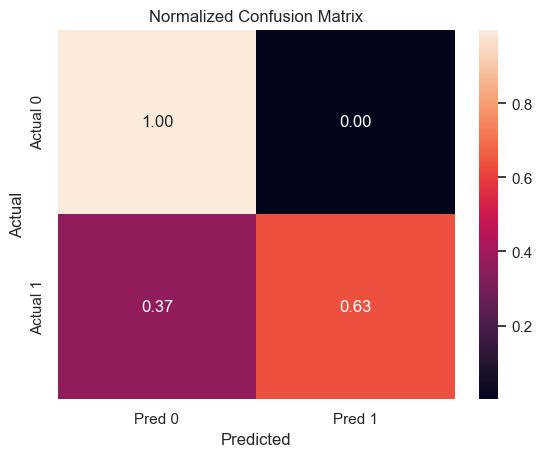

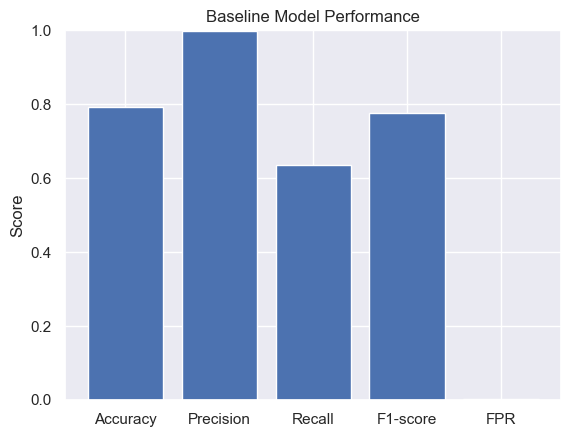

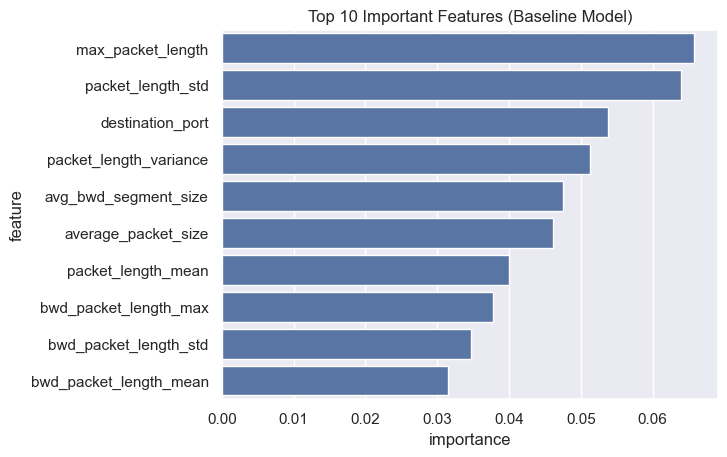

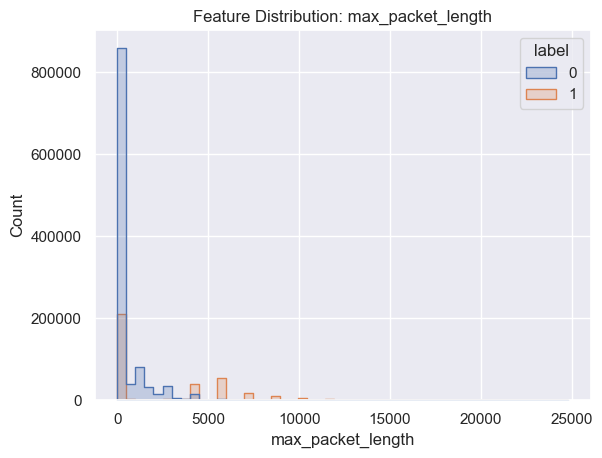

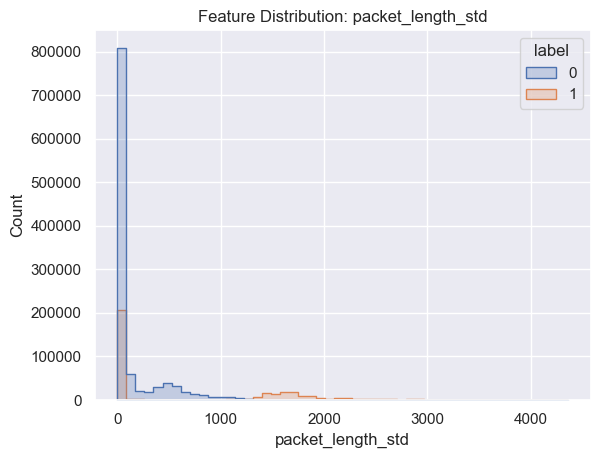

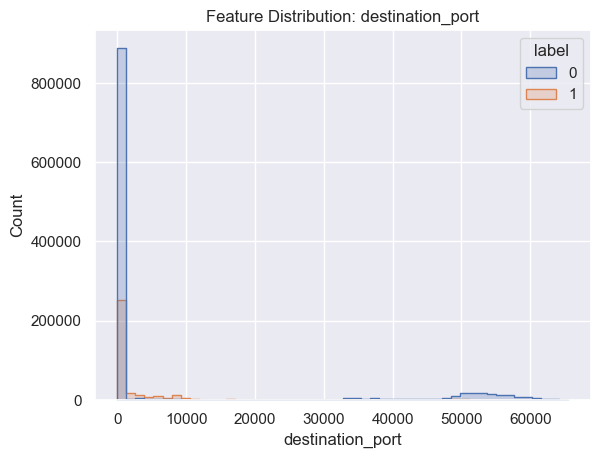

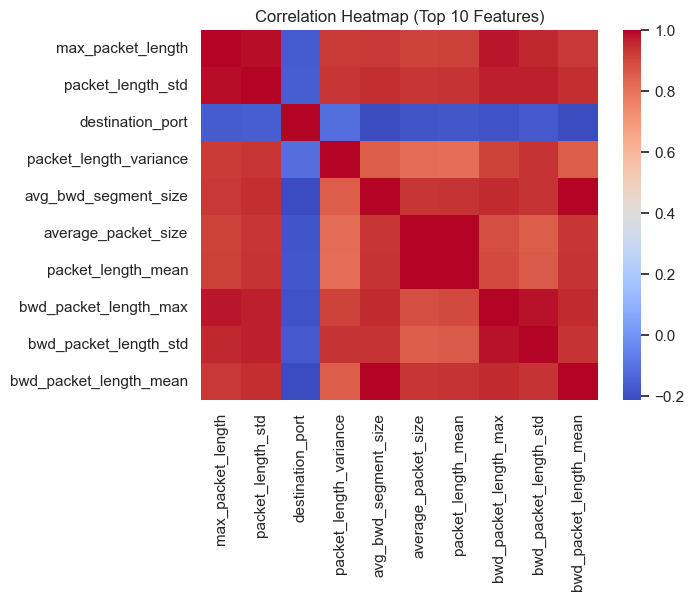

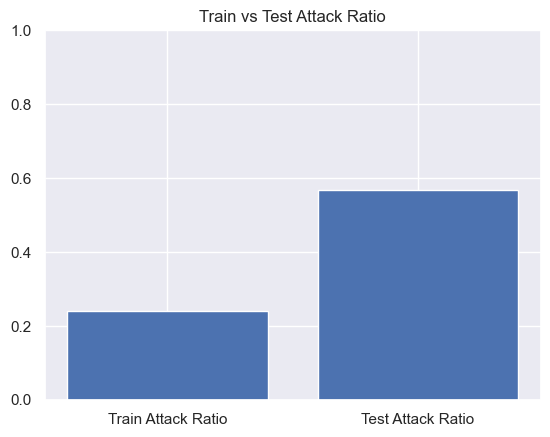

In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set()

#converted x_train and y_train value to pandas series for data visualization    
y_train_series = pd.Series(y_train, name="label")
y_test_series = pd.Series(y_test, name="label")

# build a train_df only for analysis plots
train_df = X_train.copy()
train_df["label"] = y_train_series.values


#CLASS DISTRIBUTION (TRAIN)

plt.figure()
y_train_series.value_counts().sort_index().plot(kind="bar")

plt.title("Training Data Class Distribution")
plt.xlabel("Class (0 = Benign, 1 = Attack)")
plt.ylabel("Count")
plt.show()


#CLASS DISTRIBUTION

plt.figure()
y_test_series.value_counts().sort_index().plot(kind="bar")

plt.title("Test Data Class Distribution")
plt.xlabel("Class (0 = Benign, 1 = Attack)")
plt.ylabel("Count")
plt.show()


#CONFUSION MATRIX (TEST)

test_cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure()
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#NORMALIZED CONFUSION MATRIX

cm_normalized = test_cm.astype(float) / test_cm.sum(axis=1, keepdims=True)

plt.figure()
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 
# METRICS BAR CHART

tn, fp, fn, tp = test_cm.ravel()
test_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "FPR": test_fpr
}

plt.figure()
plt.bar(metrics.keys(), metrics.values())

plt.title("Baseline Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()


#FEATURE IMPORTANCE (TOP 10)

importances = model.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure()
sns.barplot(
    x="importance",
    y="feature",
    data=feat_df.head(10)
)

plt.title("Top 10 Important Features (Baseline Model)")
plt.show()


# 7. FEATURE DISTRIBUTION (BENIGN vs ATTACK)

top_features = feat_df["feature"].head(3).tolist()

for feature in top_features:
    plt.figure()

    sns.histplot(
        data=train_df,
        x=feature,
        hue="label",
        bins=50,
        kde=False,
        element="step"
    )

    plt.title(f"Feature Distribution: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()


# 8. CORRELATION HEATMAP (TOP FEATURES ONLY)

top_corr_features = feat_df["feature"].head(10).tolist()
corr_matrix = train_df[top_corr_features].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

plt.title("Correlation Heatmap (Top 10 Features)")
plt.show()


#TRAIN VS TEST DISTRIBUTION

train_ratio = y_train_series.mean()
test_ratio = y_test_series.mean()

plt.figure()
plt.bar(["Train Attack Ratio", "Test Attack Ratio"], [train_ratio, test_ratio])

plt.title("Train vs Test Attack Ratio")
plt.ylim(0, 1)
plt.show()



In [16]:
print("=" * 40)
print("BASELINE MODEL RESULTS (All 78 Features)")
print("=" * 40)
print(f"Accuracy:            {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:           {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Det. Rate):  {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:            {f1_score(y_test, y_pred):.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"Features Used:       {X_train.shape[1]}")

BASELINE MODEL RESULTS (All 78 Features)
Accuracy:            0.7923
Precision:           0.9989
Recall (Det. Rate):  0.6345
F1-Score:            0.7761
False Positive Rate: 0.0009
Features Used:       78
